In [1]:
### Datos Sinteticos
### Librerias SDV


In [2]:
#Importamos librerias basicas
import pandas as pd
import numpy as np
import random 

In [3]:
# Importamos librerias para datos sinteticos 
import sdv
import sdmetrics

In [4]:
# Importamos sublibrerias para la generacion de datos 
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [5]:
# Importamos sublibrerias para la evaluacion de datos
from sdmetrics.reports.single_table import QualityReport

In [6]:
print("SDV:", sdv.__version__)
print("SDMetrics: ", sdmetrics.__version__)

SDV: 1.37.0
SDMetrics:  0.28.0


In [7]:
# Creamos una tabla de datos real como base para la generacion de datos sinteticos
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad": [17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual": [1800, 2000,2500,15000,18000,35000,7000,15000,4000,5000],
        "ciudad" : ["Potrero Nuevo", "Atoyac", "Cuichapa", "Cordoba", "Cuitlahuac", "Orizaba", "Yanga", "Carrillo Puerto", "Zapote", "Fortin"]
    }
)

In [8]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudad
0,1,17,1800,Potrero Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Cordoba
4,5,32,18000,Cuitlahuac
5,6,42,35000,Orizaba
6,7,70,7000,Yanga
7,8,28,15000,Carrillo Puerto
8,9,23,4000,Zapote
9,10,22,5000,Fortin


### Obtener los metadata del DataFrame generado

In [9]:
# Creamos una instancia de SingleTableMetadata
metadata = SingleTableMetadata()

In [10]:
metadata.detect_from_dataframe(
    data= dfClientes
)

In [11]:
metadata.to_dict()

{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'primary_key': 'cliente_id'}

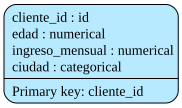

In [12]:
metadata.visualize()

In [13]:
### Entrenar el modelo de datos sinteticos 


In [14]:
# Le pasamos los metadatos
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\eduar\anaconda3\envs\Extraccion9AVS\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\eduar\anaconda3\envs\Extraccion9AVS\Lib\site-packages\sdv\single_table\base.py:138: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [16]:
# Entrenamos el sintetizador con los datos "Reales"
sintetizador.fit(
    dfClientes
)

In [20]:
# Genramos los datos sinteticos
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [21]:
dfClientes_falsos.head()


,cliente_id,edad,ingreso_mensual,ciudad
0,9377199,18,2196,Atoyac
1,2031974,18,3967,Carrillo Puerto
2,5464438,18,2190,Cuitlahuac
3,3224426,18,3528,Carrillo Puerto
4,1760189,24,12591,Cuichapa


In [22]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudad           200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [23]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,7.964678e+06,26.810000,11197.165000
std,4.867522e+06,12.854184,9047.603689
min,1.896240e+05,18.000000,2000.000000
25%,3.527745e+06,18.000000,3217.750000
50%,7.562856e+06,20.000000,9306.500000
75%,1.269630e+07,30.500000,16921.500000
max,1.673568e+07,70.000000,35000.000000


In [24]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,10530.000000
std,3.02765,16.063762,10507.568701
min,1.00000,17.000000,1800.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,6000.000000
75%,7.75000,31.000000,15000.000000
max,10.00000,70.000000,35000.000000


# Evaluamos los datos para validar
1. Similitud entre las columnas
2. Similitud entre las relaciones de las columnas (Evaluating Column Per Trends)
3. Evaluamos del dataset general

In [27]:
# Evaluamos la calidad de los datos
# Creamos una instancia de QualityReport
reporte = QualityReport()

### Puntos de referencia 

|Score | Interpretacion|
|---------|-------|
|1 | Identicas |
|0.9 | Muy similar |
|0.7 | Similar |
|0.6 | Diferencias visibles |
|<0.5 | Muy diferentes |    

In [26]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 235.31it/s]|
Column Shapes Score: 75.83%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 60.44it/s]|
Column Pair Trends Score: 22.25%

Overall Score (Average): 49.04%

